# Indoor 6G Resource Allocation Simulation Notebook


includes:
- indoor 2D robot mobility on dedicated factory lanes
- 2 base stations in factory corners
- distance logging for every slot
- 3GPP-based Indoor Office LOS/NLOS channel
- simple packet queues for eMBB (camera upload from robot) and URLLC (sensing and/or control packets)
- deadline handling and packet success/failure
- scheduler comparison: Round Robin (RR) vs Proportional Fair (PF) vs Deadline Priority
- simple plots for layout and KPI comparison

Assumption:
- Uplink-only model (robots send both traffic types to BS).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
 

## 1) References used for channel constants

We use common constants from 3GPP Indoor Office models:
- 3GPP TR 38.901 (channel model reference)
- LOS probability and pathloss constants mirrored by ns-3 3GPP model implementation

Refs:
- https://www.3gpp.org/ftp/Specs/archive/38_series/38.901/
- https://github.com/nsnam/ns-3-dev-git/blob/master/src/propagation/model/channel-condition-model.cc
- https://github.com/nsnam/ns-3-dev-git/blob/master/src/propagation/model/three-gpp-propagation-loss-model.cc


In [ ]:
# ============================
# 2) Global Configuration 
# ============================

CFG = {
    # simulation timing
    "seed": 2026,
    "sim_time_s": 60.0,   # total simulation time [s]
    "slot_s": 0.05,       # scheduler time step [s] (50 ms)

    # factory geometry and topology
    "factory_w_m": 30.0,  # factory width [m]
    "factory_h_m": 16.0,  # factory height [m]
    "n_robots": 3,
    "bs_xy_m": np.array([[0.5, 0.5], [29.5, 15.5]], dtype=float),  # BS coordinates [m]

    # lane-based mobility (2x2 lane grid)
    "lanes_x_n": 2,       # number of vertical lanes (constant x positions)
    "lanes_y_n": 2,       # number of horizontal lanes (constant y positions)
    "v_min_mps": 0.5,     # minimum robot speed [m/s]
    "v_max_mps": 1.2,     # maximum robot speed [m/s]
    "lane_switch_prob": 0.03,  # per-slot probability that a robot switches lane orientation

    # communication / channel parameters
    "fc_GHz": 3.5,        # carrier frequency [GHz]
    "bandwidth_Hz": 2.0e6,  # system bandwidth [Hz]
    "tx_power_dBm": 3.0,  # per-link TX power [dBm]
    "noise_figure_dB": 7.0,
    "bs_height_m": 4.5,
    "robot_height_m": 1.2,
    "shadow_sigma_los_dB": 3.0,   # shadowing std for LOS links [dB]
    "shadow_sigma_nlos_dB": 8.03, # shadowing std for NLOS links [dB]

    # traffic model (Bernoulli packet arrivals per slot)
    "traffic": {
        "embb": {
            "arrival_prob": 0.30,     # probability of one eMBB packet arrival per robot per slot
            "bits_min": 180_000,      # minimum packet size [bits]
            "bits_max": 260_000,      # maximum packet size [bits]
            "deadline_s": 1.5,        # packet deadline [s] before packet is dropped
        },
        "urllc": {
            "arrival_prob": 0.25,     # probability of one URLLC packet arrival per robot per slot
            "bits_min": 1_200,        # minimum packet size [bits]
            "bits_max": 2_200,        # maximum packet size [bits]
            "deadline_s": 0.10,       # packet deadline [s] before packet is dropped
        },
    },

    # scheduler parameters
    "pf_alpha": 0.90,  # EWMA factor in PF average-rate update (higher -> slower update)
    "eps": 1e-9,       # tiny numerical guard to avoid divide-by-zero in PF/SINR calculations

    # plotting helper
    "distance_plot_bs_index": 0,  # choose which BS index to visualize in the distance plot
}

# derived values
CFG["n_slots"] = int(CFG["sim_time_s"] / CFG["slot_s"])
CFG["n_bs"] = CFG["bs_xy_m"].shape[0]

# convert deadlines from seconds to integer slots for queue deadline checks
for cls in ["embb", "urllc"]:
    CFG["traffic"][cls]["deadline_slots"] = max(1, int(np.ceil(CFG["traffic"][cls]["deadline_s"] / CFG["slot_s"])))

print(f"n_slots={CFG['n_slots']}, n_bs={CFG['n_bs']}, n_robots={CFG['n_robots']}")
print("deadlines (slots):", {k: CFG["traffic"][k]["deadline_slots"] for k in ["embb", "urllc"]})


n_slots=1200, n_bs=2, n_robots=3
deadlines (slots): {'embb': 30, 'urllc': 2}


## 3) Mobility and distance logging (factory lanes)

Robots move on a 2x2 lane grid:
- `lanes_x_n`: number of vertical lanes
- `lanes_y_n`: number of horizontal lanes
- robots move back and forth on one lane and occasionally switch orientation/lane

Distances are saved for every slot for every BS-user pair with shape `[time, bs, robot]`.


In [72]:
def lane_centers(total_len, n_lanes):
    # equally spaced lane centers away from walls
    idx = np.arange(1, n_lanes + 1)
    return idx * total_len / (n_lanes + 1)


def simulate_robot_positions(cfg, rng):
    # lane-based motion inside factory: robots move along horizontal/vertical lanes
    T = cfg["n_slots"]
    U = cfg["n_robots"]
    dt = cfg["slot_s"]

    w = cfg["factory_w_m"]
    h = cfg["factory_h_m"]

    x_lanes = lane_centers(w, cfg["lanes_x_n"])
    y_lanes = lane_centers(h, cfg["lanes_y_n"])

    pos = np.zeros((T, U, 2), dtype=float)

    speed = rng.uniform(cfg["v_min_mps"], cfg["v_max_mps"], U)
    direction = rng.choice(np.array([-1.0, 1.0]), size=U)

    # mode 0: horizontal lane, mode 1: vertical lane
    mode = np.arange(U) % 2
    lane_x_id = rng.integers(0, len(x_lanes), U)
    lane_y_id = rng.integers(0, len(y_lanes), U)

    # initialize robots on lanes
    for u in range(U):
        if mode[u] == 0:
            pos[0, u, 0] = rng.uniform(0.0, w)
            pos[0, u, 1] = y_lanes[lane_y_id[u]]
        else:
            pos[0, u, 0] = x_lanes[lane_x_id[u]]
            pos[0, u, 1] = rng.uniform(0.0, h)

    for t in range(1, T):
        pos[t] = pos[t - 1]

        # occasional lane-mode change so robots cross the 2x2 lane grid
        switch_lane = rng.random(U) < cfg["lane_switch_prob"]

        for u in range(U):
            if switch_lane[u]:
                mode[u] = 1 - mode[u]
                if mode[u] == 0:
                    lane_y_id[u] = int(np.argmin(np.abs(y_lanes - pos[t, u, 1])))
                    pos[t, u, 1] = y_lanes[lane_y_id[u]]
                else:
                    lane_x_id[u] = int(np.argmin(np.abs(x_lanes - pos[t, u, 0])))
                    pos[t, u, 0] = x_lanes[lane_x_id[u]]

            step = direction[u] * speed[u] * dt

            if mode[u] == 0:
                # horizontal lane motion
                pos[t, u, 0] += step
                if pos[t, u, 0] < 0.0:
                    pos[t, u, 0] = 0.0
                    direction[u] *= -1.0
                elif pos[t, u, 0] > w:
                    pos[t, u, 0] = w
                    direction[u] *= -1.0
                pos[t, u, 1] = y_lanes[lane_y_id[u]]
            else:
                # vertical lane motion
                pos[t, u, 1] += step
                if pos[t, u, 1] < 0.0:
                    pos[t, u, 1] = 0.0
                    direction[u] *= -1.0
                elif pos[t, u, 1] > h:
                    pos[t, u, 1] = h
                    direction[u] *= -1.0
                pos[t, u, 0] = x_lanes[lane_x_id[u]]

    return pos


def compute_distances(pos_t_u_xy, bs_xy):
    # return distances with shape [T, B, U]
    diff = pos_t_u_xy[:, None, :, :] - bs_xy[None, :, None, :]
    return np.sqrt(np.sum(diff * diff, axis=3))


## 4) Channel model (3GPP-inspired Indoor Office)

 Link level model using standard values:
- LOS probability from 2D distance
- LOS/NLOS pathloss equations
- log-normal shadowing
- thermal noise from bandwidth and noise figure



In [73]:
def los_probability_inh_office(d2d_m):
    # P_LOS = 1 (d<=5), exp(-(d-5)/70.8) (5<d<=49), 0.54*exp(-(d-49)/211.7) (d>49)
    d = np.asarray(d2d_m)
    p = np.empty_like(d, dtype=float)
    p[d <= 5.0] = 1.0
    mid = (d > 5.0) & (d <= 49.0)
    far = d > 49.0
    p[mid] = np.exp(-(d[mid] - 5.0) / 70.8)
    p[far] = 0.54 * np.exp(-(d[far] - 49.0) / 211.7)
    return np.clip(p, 0.0, 1.0)


def pathloss_inh_office_dB(d3d_m, fc_GHz, los_mask):
    # PL_LOS = 32.4 + 17.3*log10(d3D) + 20*log10(fc)
    # PL_NLOS = 17.3 + 38.3*log10(d3D) + 24.9*log10(fc)
    # PL = PL_LOS if LOS else max(PL_LOS, PL_NLOS)
    d = np.maximum(np.asarray(d3d_m), 1.0)
    pl_los = 32.4 + 17.3 * np.log10(d) + 20.0 * np.log10(fc_GHz)
    pl_nlos = 17.3 + 38.3 * np.log10(d) + 24.9 * np.log10(fc_GHz)
    return np.where(los_mask, pl_los, np.maximum(pl_los, pl_nlos))


def thermal_noise_dBm(bandwidth_Hz, noise_figure_dB):
    return -174.0 + 10.0 * np.log10(bandwidth_Hz) + noise_figure_dB


def dBm_to_W(x_dBm):
    return 10.0 ** ((np.asarray(x_dBm) - 30.0) / 10.0)


## 5) Build one reproducible scenario trace


In [74]:
def build_arrival_trace(cfg, rng):
    T = cfg["n_slots"]
    U = cfg["n_robots"]

    embb_bits = np.zeros((T, U), dtype=float)
    urllc_bits = np.zeros((T, U), dtype=float)

    p_e = cfg["traffic"]["embb"]["arrival_prob"]
    p_u = cfg["traffic"]["urllc"]["arrival_prob"]

    embb_mask = rng.random((T, U)) < p_e
    urllc_mask = rng.random((T, U)) < p_u

    embb_bits[embb_mask] = rng.integers(
        cfg["traffic"]["embb"]["bits_min"],
        cfg["traffic"]["embb"]["bits_max"] + 1,
        size=np.count_nonzero(embb_mask),
    )
    urllc_bits[urllc_mask] = rng.integers(
        cfg["traffic"]["urllc"]["bits_min"],
        cfg["traffic"]["urllc"]["bits_max"] + 1,
        size=np.count_nonzero(urllc_mask),
    )

    return {"embb_bits": embb_bits, "urllc_bits": urllc_bits}


def build_scenario_trace(cfg):
    rng = np.random.default_rng(cfg["seed"])
    T = cfg["n_slots"]
    B = cfg["n_bs"]
    U = cfg["n_robots"]

    pos = simulate_robot_positions(cfg, rng)
    bs_xy = cfg["bs_xy_m"]
    d2d = compute_distances(pos, bs_xy)

    dh = cfg["bs_height_m"] - cfg["robot_height_m"]
    d3d = np.sqrt(d2d * d2d + dh * dh)

    p_los = los_probability_inh_office(d2d)
    los = rng.random((T, B, U)) < p_los

    pl = pathloss_inh_office_dB(d3d, cfg["fc_GHz"], los)
    shadow_sigma = np.where(los, cfg["shadow_sigma_los_dB"], cfg["shadow_sigma_nlos_dB"])
    pl = pl + rng.normal(0.0, shadow_sigma)

    noise_dBm = thermal_noise_dBm(cfg["bandwidth_Hz"], cfg["noise_figure_dB"])
    rx_dBm = cfg["tx_power_dBm"] - pl
    snr_dB = rx_dBm - noise_dBm
    rate_no_int = cfg["bandwidth_Hz"] * np.log2(1.0 + 10.0 ** (snr_dB / 10.0))

    arrivals = build_arrival_trace(cfg, rng)

    return {
        "pos": pos,
        "d2d": d2d,
        "d3d": d3d,
        "los": los,
        "pl_dB": pl,
        "rx_dBm": rx_dBm,
        "noise_dBm": noise_dBm,
        "rate_no_int_bps": rate_no_int,
        "arrivals": arrivals,
    }


trace = build_scenario_trace(CFG)

print("trace keys:", list(trace.keys()))
print("distance tensor [T,B,U] shape:", trace["d2d"].shape)
print("LOS fraction in generated trace:", float(np.mean(trace["los"])))


trace keys: ['pos', 'd2d', 'd3d', 'los', 'pl_dB', 'rx_dBm', 'noise_dBm', 'rate_no_int_bps', 'arrivals']
distance tensor [T,B,U] shape: (1200, 2, 3)
LOS fraction in generated trace: 0.8430555555555556


## 6) Packet queues and service logic


In [75]:
def init_queues(U):
    return [{"embb": deque(), "urllc": deque()} for _ in range(U)]


def add_arrivals_to_queues(queues, arrivals, t, cfg, stats):
    U = len(queues)

    # Guard against stale trace after changing CFG (e.g., n_robots)
    arr_u = arrivals["embb_bits"].shape[1]
    if arr_u != U:
        raise ValueError(
            f"Trace/CFG mismatch: arrivals have {arr_u} users but queues expect {U}. "
            "Rebuild trace by running the scenario-trace cell again (or the KPI run cell, which now auto-refreshes trace)."
        )

    for u in range(U):
        bits_e = arrivals["embb_bits"][t, u]
        bits_u = arrivals["urllc_bits"][t, u]

        if bits_e > 0:
            pkt_e = {
                "remaining": float(bits_e),
                "arrival_slot": t,
                "expire_slot": t + cfg["traffic"]["embb"]["deadline_slots"],
            }
            queues[u]["embb"].append(pkt_e)
            stats["arrivals"]["embb"] += 1
            stats["arrived_bits"]["embb"] += float(bits_e)

        if bits_u > 0:
            pkt_u = {
                "remaining": float(bits_u),
                "arrival_slot": t,
                "expire_slot": t + cfg["traffic"]["urllc"]["deadline_slots"],
            }
            queues[u]["urllc"].append(pkt_u)
            stats["arrivals"]["urllc"] += 1
            stats["arrived_bits"]["urllc"] += float(bits_u)


def drop_expired_packets(queues, t, stats):
    for q in queues:
        for cls in ["embb", "urllc"]:
            dq = q[cls]
            while dq and dq[0]["expire_slot"] <= t:
                dq.popleft()
                stats["drops"][cls] += 1


def queue_backlog_bits(queues):
    per_user = np.zeros(len(queues), dtype=float)
    for u, q in enumerate(queues):
        per_user[u] = (
            sum(pkt["remaining"] for pkt in q["embb"]) +
            sum(pkt["remaining"] for pkt in q["urllc"])
        )
    return per_user


def serve_user_packets(queues, u, bit_budget, t, cfg, stats):
    # serve URLLC first, then eMBB
    served = {"embb": 0.0, "urllc": 0.0}

    for cls in ["urllc", "embb"]:
        dq = queues[u][cls]
        while bit_budget > 0.0 and dq:
            pkt = dq[0]
            tx = min(bit_budget, pkt["remaining"])
            pkt["remaining"] -= tx
            bit_budget -= tx
            served[cls] += tx

            if pkt["remaining"] <= 1e-12:
                dq.popleft()
                stats["delivered"][cls] += 1
                delay_s = (t + 1 - pkt["arrival_slot"]) * cfg["slot_s"]
                stats["delays_s"][cls].append(delay_s)

        if bit_budget <= 0.0:
            break

    return served


## 7) Scheduler functions (RR, PF, Deadline Priority)



This simulator models **joint scheduling + implicit BS-user association per slot**.

Decision sequence each slot:
1. Traffic arrives to each user queue (`eMBB` and `URLLC`).
2. Expired packets are dropped by deadline.
3. For each BS, channel quality toward all users is known for this slot.
4. Scheduler selects one user per BS from users with backlog.
5. A user cannot be selected by two BS in the same slot.
6. Selected links transmit. SINR includes interference from other active BS.


In [76]:
def schedule_rr(backlog_users, rr_ptr, n_bs):
    U = len(backlog_users)
    selected = -np.ones(n_bs, dtype=int)
    used = set()

    for b in range(n_bs):
        for _ in range(U):
            u = rr_ptr[b] % U
            rr_ptr[b] = (rr_ptr[b] + 1) % U
            if backlog_users[u] and (u not in used):
                selected[b] = u
                used.add(u)
                break

    return selected, rr_ptr


def schedule_pf(backlog_users, expected_rate_bu, avg_user_rate, n_bs, eps=1e-9):
    U = len(backlog_users)
    selected = -np.ones(n_bs, dtype=int)
    used = set()

    for b in range(n_bs):
        cand = [u for u in range(U) if backlog_users[u] and (u not in used)]
        if not cand:
            continue

        cand = np.asarray(cand, dtype=int)
        metric = expected_rate_bu[b, cand] / (avg_user_rate[cand] + eps)
        pick = cand[np.argmax(metric)]

        selected[b] = int(pick)
        used.add(int(pick))

    return selected


def earliest_deadline_remaining_slots(queues, now_slot):
    # smaller value means more urgent packet deadline
    U = len(queues)
    rem = np.full(U, np.inf, dtype=float)

    for u in range(U):
        for cls in ["urllc", "embb"]:
            q = queues[u][cls]
            if q:
                # queue is FIFO; head packet has earliest deadline for that class
                rem[u] = min(rem[u], q[0]["expire_slot"] - now_slot)

    return rem


def schedule_deadline(backlog_users, deadline_remaining_u, expected_rate_bu, n_bs):
    # earliest deadline first; tie-break with higher expected rate on each BS
    U = len(backlog_users)
    selected = -np.ones(n_bs, dtype=int)
    used = set()

    for b in range(n_bs):
        cand = [u for u in range(U) if backlog_users[u] and (u not in used)]
        if not cand:
            continue

        best_u = None
        best_deadline = np.inf
        best_rate = -1.0

        for u in cand:
            dleft = deadline_remaining_u[u]
            rate = expected_rate_bu[b, u]
            if (dleft < best_deadline) or (dleft == best_deadline and rate > best_rate):
                best_deadline = dleft
                best_rate = rate
                best_u = u

        selected[b] = int(best_u)
        used.add(int(best_u))

    return selected


## 8) End-to-end simulation for one scheduler


In [77]:
def run_simulation(cfg, trace, scheduler_name):
    T = cfg["n_slots"]
    B = cfg["n_bs"]
    U = cfg["n_robots"]

    queues = init_queues(U)
    rr_ptr = np.arange(B)
    avg_user_rate = np.full(U, 1e3, dtype=float)

    stats = {
        "scheduler": scheduler_name,
        "arrivals": {"embb": 0, "urllc": 0},
        "arrived_bits": {"embb": 0.0, "urllc": 0.0},
        "delivered": {"embb": 0, "urllc": 0},
        "drops": {"embb": 0, "urllc": 0},
        "delays_s": {"embb": [], "urllc": []},
        "served_bits": {"embb": 0.0, "urllc": 0.0},
        "served_user_bits": np.zeros(U, dtype=float),
        "scheduled_users": -np.ones((T, B), dtype=int),
        "backlog_bits": np.zeros(T, dtype=float),
    }

    tx_power_W = dBm_to_W(cfg["tx_power_dBm"])
    noise_W = dBm_to_W(trace["noise_dBm"])

    for t in range(T):
        # arrivals and deadline drops
        add_arrivals_to_queues(queues, trace["arrivals"], t, cfg, stats)
        drop_expired_packets(queues, t, stats)

        # users with pending packets
        backlog_per_user = queue_backlog_bits(queues)
        has_backlog = backlog_per_user > 0.0

        # schedule per BS
        if scheduler_name == "rr":
            selected, rr_ptr = schedule_rr(has_backlog, rr_ptr, B)
        elif scheduler_name == "pf":
            selected = schedule_pf(has_backlog, trace["rate_no_int_bps"][t], avg_user_rate, B, cfg["eps"])
        elif scheduler_name == "deadline":
            deadline_left = earliest_deadline_remaining_slots(queues, t)
            selected = schedule_deadline(has_backlog, deadline_left, trace["rate_no_int_bps"][t], B)
        else:
            raise ValueError("scheduler_name must be 'rr', 'pf', or 'deadline'")

        stats["scheduled_users"][t] = selected

        inst_user_rate = np.zeros(U, dtype=float)

        for b in range(B):
            u = int(selected[b])
            if u < 0:
                continue

            # desired signal at scheduled user
            pl_bu_dB = trace["pl_dB"][t, b, u]
            signal_W = tx_power_W * 10.0 ** (-pl_bu_dB / 10.0)

            # interference from other active BS
            interf_W = 0.0
            for b2 in range(B):
                if b2 == b:
                    continue
                if int(selected[b2]) < 0:
                    continue
                pl_b2u_dB = trace["pl_dB"][t, b2, u]
                interf_W += tx_power_W * 10.0 ** (-pl_b2u_dB / 10.0)

            sinr = signal_W / (noise_W + interf_W + cfg["eps"])
            rate_bps = cfg["bandwidth_Hz"] * np.log2(1.0 + sinr)
            bit_budget = rate_bps * cfg["slot_s"]

            served = serve_user_packets(queues, u, bit_budget, t, cfg, stats)
            served_u = served["embb"] + served["urllc"]

            stats["served_bits"]["embb"] += served["embb"]
            stats["served_bits"]["urllc"] += served["urllc"]
            stats["served_user_bits"][u] += served_u
            inst_user_rate[u] += served_u / cfg["slot_s"]

        # PF moving-average throughput
        avg_user_rate = cfg["pf_alpha"] * avg_user_rate + (1.0 - cfg["pf_alpha"]) * inst_user_rate

        stats["backlog_bits"][t] = np.sum(queue_backlog_bits(queues))

    return stats


## 9) KPI helper and experiment run

We summarize each scheduler with:
- offered and served throughput
- packet success for eMBB/URLLC
- mean and p95 packet delay

`safe_mean` and `safe_p95` avoid crashing when a metric list is empty.


In [ ]:
def safe_mean(x):
    # return NaN when list is empty instead of raising a warning/error
    return float(np.mean(x)) if len(x) > 0 else np.nan


def safe_p95(x):
    # 95th percentile (tail delay); return NaN when list is empty
    return float(np.percentile(x, 95)) if len(x) > 0 else np.nan


def summarize_stats(stats, cfg):
    total_arr_bits = stats["arrived_bits"]["embb"] + stats["arrived_bits"]["urllc"]
    total_srv_bits = stats["served_bits"]["embb"] + stats["served_bits"]["urllc"]

    offered_rate = total_arr_bits / cfg["sim_time_s"]
    served_rate = total_srv_bits / cfg["sim_time_s"]

    return {
        "scheduler": stats["scheduler"],
        "offered_Mbps": offered_rate / 1e6,
        "served_Mbps": served_rate / 1e6,
        "load_ratio_offered_over_served": offered_rate / max(served_rate, cfg["eps"]),
        "embb_success": stats["delivered"]["embb"] / max(stats["arrivals"]["embb"], 1),
        "urllc_success": stats["delivered"]["urllc"] / max(stats["arrivals"]["urllc"], 1),
        "embb_delay_mean_ms": 1e3 * safe_mean(stats["delays_s"]["embb"]),
        "urllc_delay_mean_ms": 1e3 * safe_mean(stats["delays_s"]["urllc"]),
        "embb_delay_p95_ms": 1e3 * safe_p95(stats["delays_s"]["embb"]),
        "urllc_delay_p95_ms": 1e3 * safe_p95(stats["delays_s"]["urllc"]),
    }


#  rebuild trace from current CFG 
trace = build_scenario_trace(CFG)

rr_stats = run_simulation(CFG, trace, "rr")
pf_stats = run_simulation(CFG, trace, "pf")
deadline_stats = run_simulation(CFG, trace, "deadline")

kpi_df = pd.DataFrame([
    summarize_stats(rr_stats, CFG),
    summarize_stats(pf_stats, CFG),
    summarize_stats(deadline_stats, CFG),
])
kpi_df


,scheduler,offered_Mbps,served_Mbps,load_ratio_offered_over_served,embb_success,urllc_success,embb_delay_mean_ms,urllc_delay_mean_ms,embb_delay_p95_ms,urllc_delay_p95_ms
0,rr,3.97076,2.352607,1.687813,0.324048,0.944561,1273.065903,67.331118,1500.0,100.0
1,pf,3.97076,3.110141,1.276714,0.604457,0.884937,1129.953917,62.765957,1500.0,100.0
2,deadline,3.97076,2.781962,1.427324,0.453110,0.986402,1308.811475,56.627784,1500.0,100.0


## 10) Plots layout and scheduling result comparison


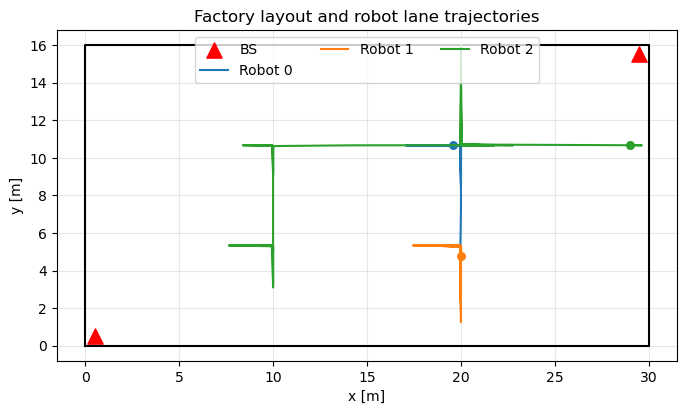

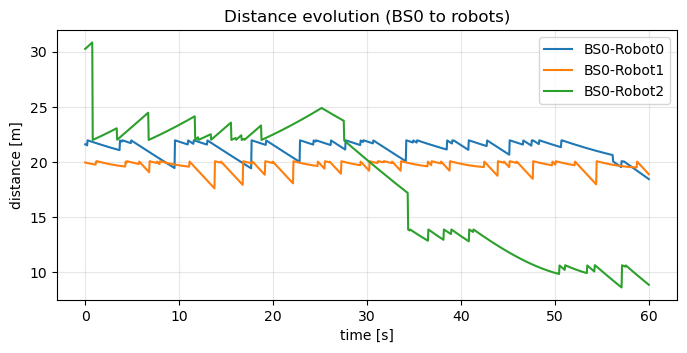

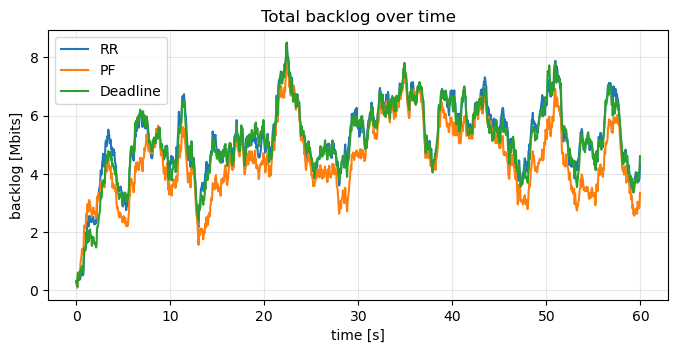

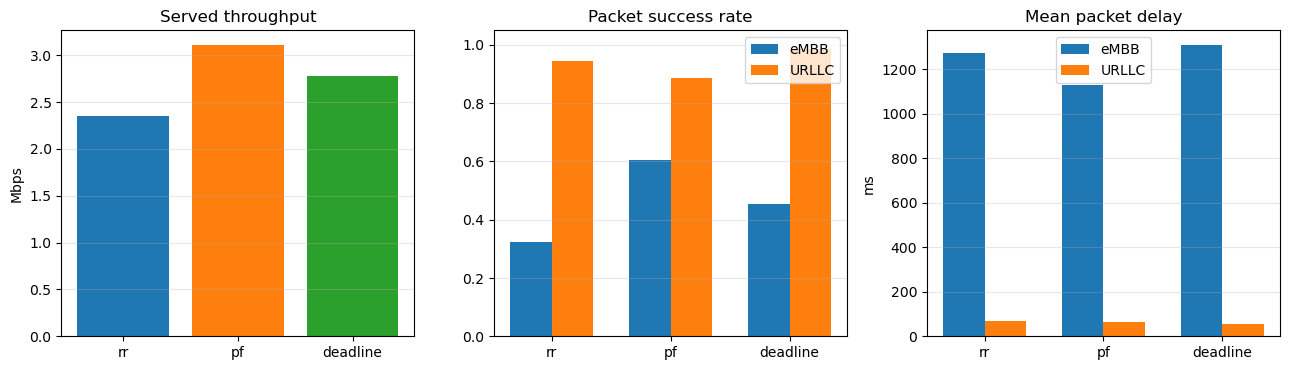

In [79]:
# Plot A: factory layout + trajectories
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot([0, CFG["factory_w_m"], CFG["factory_w_m"], 0, 0], [0, 0, CFG["factory_h_m"], CFG["factory_h_m"], 0], "k-")

bs = CFG["bs_xy_m"]
ax.scatter(bs[:, 0], bs[:, 1], c="red", marker="^", s=120, label="BS")

for u in range(CFG["n_robots"]):
    xy = trace["pos"][:, u, :]
    ax.plot(xy[:, 0], xy[:, 1], lw=1.5, label=f"Robot {u}")
    ax.scatter(xy[0, 0], xy[0, 1], s=30)

ax.set_title("Factory layout and robot lane trajectories")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper center", ncol=3)
plt.show()

# Plot B: distance evolution from selected BS
bs_idx = int(np.clip(CFG.get("distance_plot_bs_index", 0), 0, CFG["n_bs"] - 1))
t = np.arange(CFG["n_slots"]) * CFG["slot_s"]
fig, ax = plt.subplots(figsize=(8, 3.5))
for u in range(CFG["n_robots"]):
    ax.plot(t, trace["d2d"][:, bs_idx, u], label=f"BS{bs_idx}-Robot{u}")
ax.set_title(f"Distance evolution (BS{bs_idx} to robots)")
ax.set_xlabel("time [s]")
ax.set_ylabel("distance [m]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Plot C: backlog comparison
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t, rr_stats["backlog_bits"] / 1e6, label="RR")
ax.plot(t, pf_stats["backlog_bits"] / 1e6, label="PF")
ax.plot(t, deadline_stats["backlog_bits"] / 1e6, label="Deadline")
ax.set_title("Total backlog over time")
ax.set_xlabel("time [s]")
ax.set_ylabel("backlog [Mbits]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Plot D: KPI bars
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
names = kpi_df["scheduler"].tolist()
x = np.arange(len(names))
w = 0.35

axs[0].bar(names, kpi_df["served_Mbps"].values, color=["tab:blue", "tab:orange", "tab:green"])
axs[0].set_title("Served throughput")
axs[0].set_ylabel("Mbps")
axs[0].grid(True, axis="y", alpha=0.3)

axs[1].bar(x - w / 2, kpi_df["embb_success"].values, width=w, label="eMBB")
axs[1].bar(x + w / 2, kpi_df["urllc_success"].values, width=w, label="URLLC")
axs[1].set_xticks(x)
axs[1].set_xticklabels(names)
axs[1].set_ylim(0, 1.05)
axs[1].set_title("Packet success rate")
axs[1].grid(True, axis="y", alpha=0.3)
axs[1].legend()

axs[2].bar(x - w / 2, kpi_df["embb_delay_mean_ms"].values, width=w, label="eMBB")
axs[2].bar(x + w / 2, kpi_df["urllc_delay_mean_ms"].values, width=w, label="URLLC")
axs[2].set_xticks(x)
axs[2].set_xticklabels(names)
axs[2].set_title("Mean packet delay")
axs[2].set_ylabel("ms")
axs[2].grid(True, axis="y", alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()
